In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.utils import to_categorical
import random
!pip install np_utils

np.random.seed(0)

(X_train , y_train) , (X_test , y_test) = mnist.load_data()
num_of_samples = []
cols=5
num_classes=10

# fig,axs = plt.subplots(nrows = num_classes , ncols = cols ,figsize=(5,10) )
# fig.tight_layout()
# num_of_samples = []
# cols=5
# num_classes=10

# fig,axs = plt.subplots(nrows = num_classes , ncols = cols ,figsize=(5,10) )
# fig.tight_layout()
# for i in range(cols):
#     for j in range(num_classes):
#         x_selected = X_train[y_train==j]
#         axs[j][i].imshow(x_selected[random.randint(0 , len(x_selected)-1) , : , :] , cmap = plt.get_cmap('gray'))
#         axs[j][i].axis('off')
#         if i==2:
#             axs[j][i].set_title(str(j))
#             num_of_samples.append(len(x_selected))
# print(num_of_samples)


y_train = to_categorical(y_train , 10)
y_test = to_categorical(y_test , 10)

X_train = X_train.reshape(60000 , 28,28,1)
X_test = X_test.reshape(10000,28,28,1)

X_test=X_test/255
X_train=X_train/255




In [2]:
from keras.layers import Conv2D , MaxPooling2D , Flatten

In [6]:
def Lenet_model():
    model = Sequential()
    model.add(Conv2D(30 , (5,5) , input_shape=(28,28,1) , activation='relu'))
    model.add(Conv2D(30 , (5,5) ,  activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Conv2D(15 , (3,3) , activation = 'relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Flatten())
    model.add(Dense(200 , activation='relu'))
    model.add(Dense(100 , activation = 'relu'))
    model.add(Dense(num_classes , activation = 'softmax'))
    model.compile(Adam(learning_rate = 0.01) , loss='categorical_crossentropy' , metrics=['accuracy'])

    return model

In [7]:
model = Lenet_model()

d:\PYTHON\deeplearning\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 30)     │           780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 20, 20, 30)     │        22,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 15)       │         4,065 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 15)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 240)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 200)            │        48,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,685 (377.68 KB)

 Trainable params: 96,685 (377.68 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(X_train , y_train , validation_split=0.1 , epochs=50 , batch_size=400 , verbose=1 , shuffle=1)

Epoch 1/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 0.7678 - loss: 0.6895 - val_accuracy: 0.9817 - val_loss: 0.0652
Epoch 2/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.9815 - loss: 0.0625 - val_accuracy: 0.9848 - val_loss: 0.0521
Epoch 3/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.9846 - loss: 0.0478 - val_accuracy: 0.9855 - val_loss: 0.0523
Epoch 4/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 0.9868 - loss: 0.0442 - val_accuracy: 0.9855 - val_loss: 0.0442
Epoch 5/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 12s 91ms/step - accuracy: 0.9901 - loss: 0.0329 - val_accuracy: 0.9897 - val_loss: 0.0366
Epoch 6/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 0.9912 - loss: 0.0297 - val_accuracy: 0.9897 - val_loss: 0.0374
Epoch 7/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 12s 91ms/step - accuracy: 0.9906 - loss: 0.0310 - val_accuracy: 0.9885 - val_loss: 0.0476
Epoch 8/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - accuracy: 0.9916 - loss: 0.0257 - 

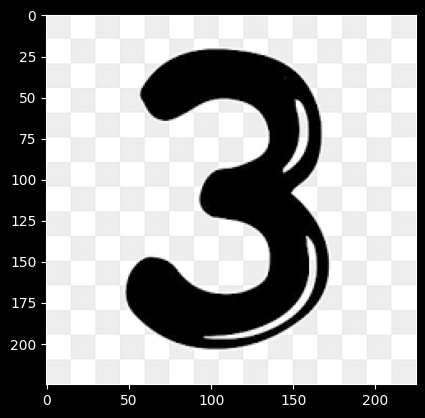

In [11]:

import cv2
a=cv2.imread('3.png')
plt.imshow(a)

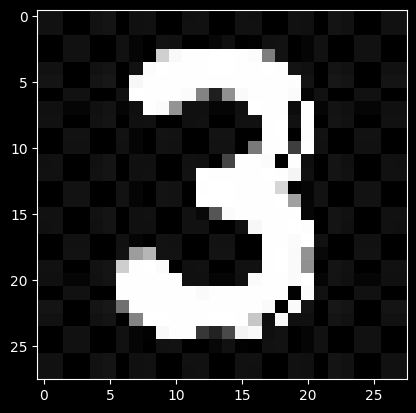

In [12]:
img = cv2.resize(a , (28,28))               
img = cv2.cvtColor(img , cv2.COLOR_BGR2GRAY)    
img = cv2.bitwise_not(img) 
plt.imshow(img , cmap='gray')


In [13]:
img=img/255
img=img.reshape(1,28,28,1)
pred = model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


In [16]:
ans = np.argmax(pred , axis=1)
print(ans)

[3]


In [17]:
ans

array([3])